In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [12]:
data = pd.read_csv('height_weight.csv')
x=data[['height']]
y=data[['weight']]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=33)

In [14]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
x_train_tensor=torch.tensor(x_train,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
x_test_tensor=torch.tensor(x_test,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [18]:
# Name: P PARTHIBAN
# Register Number: 212223230145
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1=nn.Linear(1,8)
    self.fc2=nn.Linear(8,10)
    self.fc3=nn.Linear(10,1)
    self.relu=nn.ReLU()
    self.history={'loss':[]}

  def forward(self,x):
    x=self.relu(self.fc1(x)) # Apply relu after the first linear layer
    x=self.relu(self.fc2(x)) # Apply relu after the second linear layer
    x=self.fc3(x)
    return x





In [19]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
Parthiban = NeuralNet()
criterion=nn.MSELoss()
optimizer=torch.optim.RMSprop(Parthiban.parameters(),lr=0.001)

In [20]:
# Name: P PARTHIBAN
# Register Number: 212223230145
def train_model(Parthiban,x_train,y_train,criterion,optimizer,epochs=2000):
  for epoch in range(epochs):
    optimizer.zero_grad()
    loss=criterion(Parthiban(x_train),y_train)
    loss.backward()
    optimizer.step()

    Parthiban.history['loss'].append(loss.item())
    if epoch % 200 ==0:
      print(f"Epoch [{epoch}/{epochs}], loss: {loss.item():.6f}")

In [21]:
train_model(Parthiban,x_train_tensor,y_train_tensor,criterion,optimizer)

Epoch [0/2000], loss: 4957.760742
Epoch [200/2000], loss: 4085.847168
Epoch [400/2000], loss: 2630.959229
Epoch [600/2000], loss: 1138.560059
Epoch [800/2000], loss: 347.785767
Epoch [1000/2000], loss: 229.147919
Epoch [1200/2000], loss: 172.177963
Epoch [1400/2000], loss: 105.728065
Epoch [1600/2000], loss: 49.037987
Epoch [1800/2000], loss: 13.081740


In [22]:
with torch.no_grad():
  test_loss=criterion(Parthiban(x_test_tensor),y_test_tensor)
  print(f"Test Loss: {test_loss.item():.6f}")

Test Loss: 0.874169


Text(0, 0.5, 'Loss')

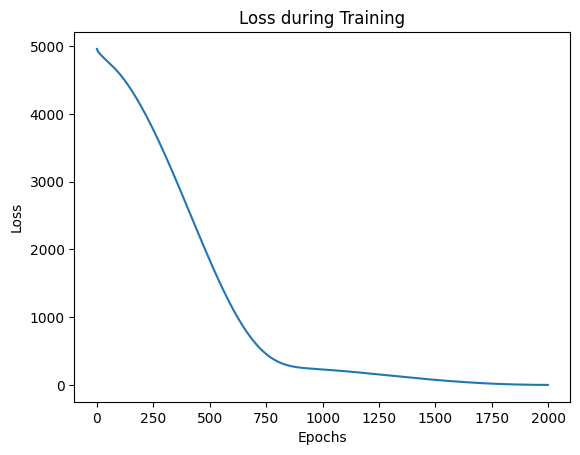

In [24]:
import matplotlib.pyplot as plt
plt.plot(Parthiban.history['loss'])
plt.title('Loss during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [26]:
import pandas as pd
X_n1_1 = torch.tensor([[105]], dtype=torch.float32)
prediction = Parthiban(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 26.509592056274414


c:\Users\parth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
